<a href="https://colab.research.google.com/github/Z3R0-2X/Statistical-Learning-e22122/blob/main/Assignment_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Install required packages
!pip install kagglehub --quiet

In [3]:
# ─── Global imports ───────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
print('Imports successful.')

Imports successful.


---
# Part 1: Gaussian Process Regression

## Dataset: Energy Efficiency

The dataset originates from a study of 12 building shapes simulated in Ecotect. It contains **8 features** (X1–X8) and **2 target responses** (Y1: Heating Load, Y2: Cooling Load). We explore single-parameter (univariate-output) Gaussian Process models for each target.

In [4]:
# ─── 1.1  Download data ───────────────────────────────────────────────────────
import kagglehub, os

kagglepath = "elikplim/eergy-efficiency-dataset"
path = kagglehub.dataset_download(kagglepath)
print("Path to dataset files:", path)
print(os.listdir(path))

100%|██████████| 6.22k/6.22k [00:00<00:00, 6.90MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/elikplim/eergy-efficiency-dataset/versions/1
['ENB2012_data.csv']


In [5]:
# ─── 1.2  Load & inspect ─────────────────────────────────────────────────────
df = pd.read_csv(path + "/ENB2012_data.csv")

# Drop any all-NaN trailing columns that sometimes appear in this CSV
df = df.dropna(axis=1, how='all').dropna(axis=0, how='any')

# Rename columns for clarity
col_names = {
    'X1': 'Relative_Compactness',
    'X2': 'Surface_Area',
    'X3': 'Wall_Area',
    'X4': 'Roof_Area',
    'X5': 'Overall_Height',
    'X6': 'Orientation',
    'X7': 'Glazing_Area',
    'X8': 'Glazing_Area_Distribution',
    'Y1': 'Heating_Load',
    'Y2': 'Cooling_Load'
}
df.rename(columns=col_names, inplace=True)

print(f"Shape: {df.shape}")
print("\nFirst 5 rows:")
df.head()

Shape: (768, 10)

First 5 rows:


,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Area_Distribution,Heating_Load,Cooling_Load
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


In [6]:
# ─── 1.3  Descriptive statistics ─────────────────────────────────────────────
df.describe().round(3)

,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Area_Distribution,Heating_Load,Cooling_Load
count,768.000,768.000,768.000,768.000,768.000,768.000,768.000,768.000,768.000,768.000
mean,0.764,671.708,318.500,176.604,5.250,3.500,0.234,2.812,22.307,24.588
std,0.106,88.086,43.626,45.166,1.751,1.119,0.133,1.551,10.090,9.513
min,0.620,514.500,245.000,110.250,3.500,2.000,0.000,0.000,6.010,10.900
25%,0.682,606.375,294.000,140.875,3.500,2.750,0.100,1.750,12.992,15.620
50%,0.750,673.750,318.500,183.750,5.250,3.500,0.250,3.000,18.950,22.080
75%,0.830,741.125,343.000,220.500,7.000,4.250,0.400,4.000,31.668,33.132
max,0.980,808.500,416.500,220.500,7.000,5.000,0.400,5.000,43.100,48.030


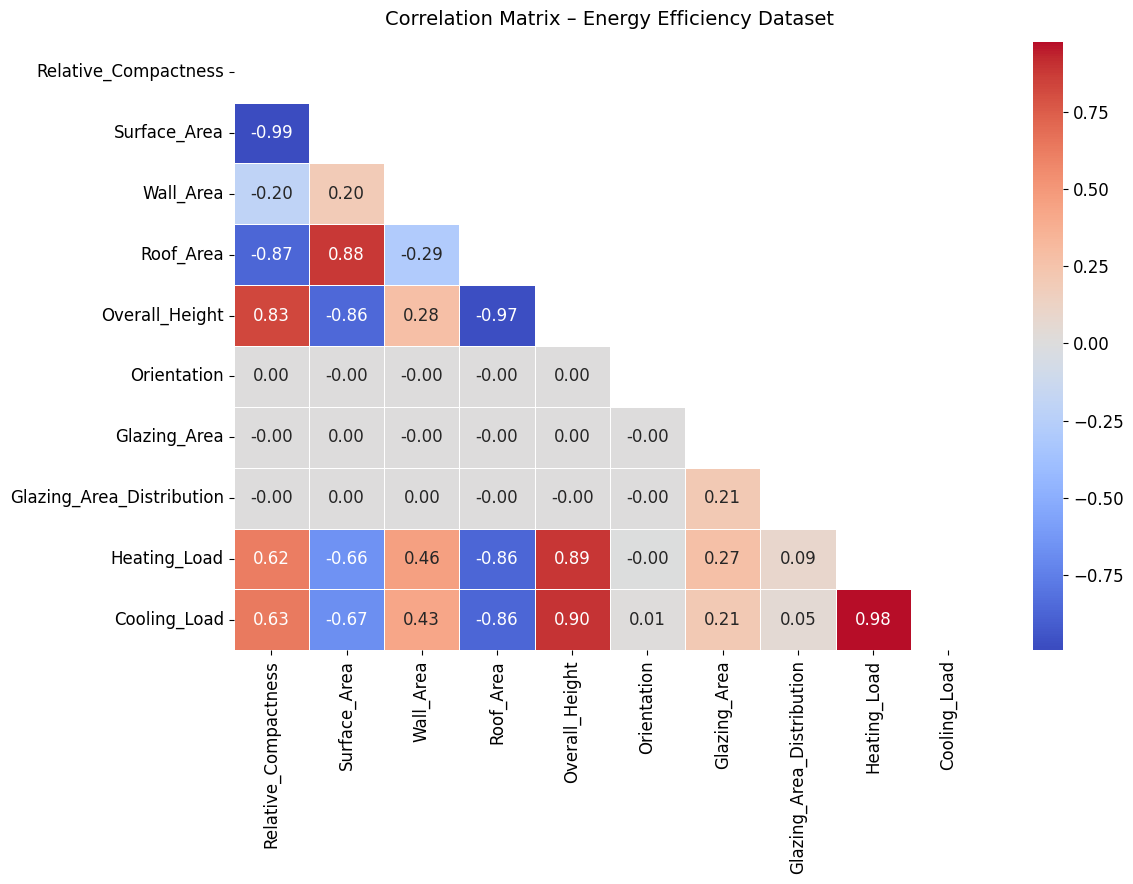


Correlation with Heating Load (Y1):
Heating_Load                 1.000000
Cooling_Load                 0.975862
Overall_Height               0.889431
Relative_Compactness         0.622272
Wall_Area                    0.455671
Glazing_Area                 0.269841
Glazing_Area_Distribution    0.087368
Orientation                 -0.002587
Surface_Area                -0.658120
Roof_Area                   -0.861828

Correlation with Cooling Load (Y2):
Cooling_Load                 1.000000
Heating_Load                 0.975862
Overall_Height               0.895785
Relative_Compactness         0.634339
Wall_Area                    0.427117
Glazing_Area                 0.207505
Glazing_Area_Distribution    0.050525
Orientation                  0.014290
Surface_Area                -0.672999
Roof_Area                   -0.862547


In [7]:
# ─── 1.4  Correlation heatmap ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 9))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5)
ax.set_title('Correlation Matrix – Energy Efficiency Dataset', fontsize=14, pad=12)
plt.tight_layout()
plt.show()

print("\nCorrelation with Heating Load (Y1):")
print(corr['Heating_Load'].sort_values(ascending=False).to_string())
print("\nCorrelation with Cooling Load (Y2):")
print(corr['Cooling_Load'].sort_values(ascending=False).to_string())

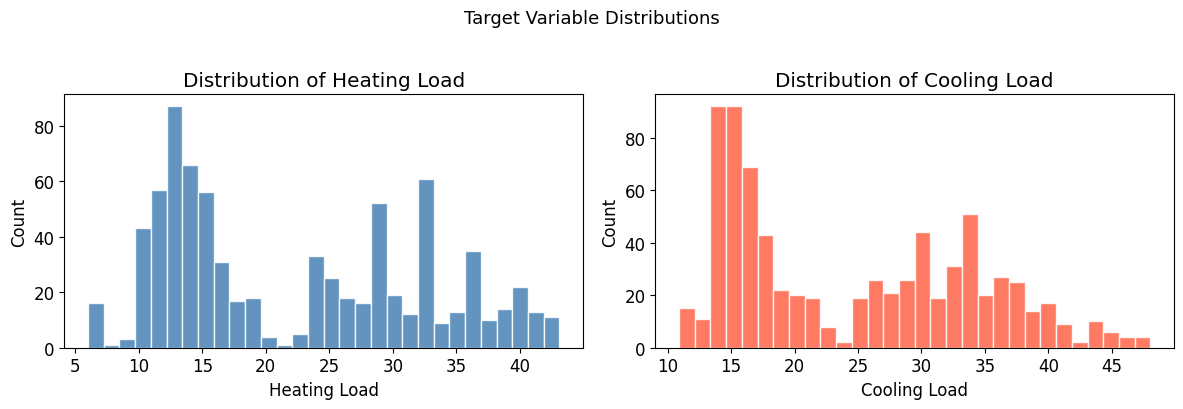

In [8]:
# ─── 1.5  Target distributions ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, color in zip(axes, ['Heating_Load', 'Cooling_Load'], ['steelblue', 'tomato']):
    ax.hist(df[col], bins=30, color=color, edgecolor='white', alpha=0.85)
    ax.set_xlabel(col.replace('_', ' '))
    ax.set_ylabel('Count')
    ax.set_title(f'Distribution of {col.replace("_", " ")}')
plt.suptitle('Target Variable Distributions', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [9]:
# ─── 1.6  Prepare features & targets ─────────────────────────────────────────
feature_cols = ['Relative_Compactness', 'Surface_Area', 'Wall_Area', 'Roof_Area',
                'Overall_Height', 'Orientation', 'Glazing_Area',
                'Glazing_Area_Distribution']
X = df[feature_cols].values
y1 = df['Heating_Load'].values
y2 = df['Cooling_Load'].values

# Standardise features (important for GPR length-scales)
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X)

# Train / test split (80 / 20, stratified by Overall_Height bins for diversity)
X_train, X_test, y1_train, y1_test, y2_train, y2_test = train_test_split(
    X_scaled, y1, y2, test_size=0.20, random_state=42)

print(f"Training samples : {X_train.shape[0]}")
print(f"Test samples     : {X_test.shape[0]}")

Training samples : 614
Test samples     : 154


## 1.7  Gaussian Process Regression

We use `sklearn.gaussian_process.GaussianProcessRegressor` with a **Radial Basis Function kernel** plus a **White Noise kernel** (to model observation noise). The hyperparameters (length-scale and noise level) are optimised by maximising the log-marginal likelihood.

We fit **two separate single-output GP models**: one for Heating Load (Y1) and one for Cooling Load (Y2).

In [10]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, Matern, ConstantKernel as C

# ── Kernel: Constant amplitude × RBF + White noise ───────────────────────────
kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2)) \
       + WhiteKernel(noise_level=1.0, noise_level_bounds=(1e-5, 1e2))

# ── GP for Heating Load ───────────────────────────────────────────────────────
gpr_y1 = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=5,
                                   normalize_y=True, random_state=42)
gpr_y1.fit(X_train, y1_train)
print("Heating Load GP")
print(f"  Optimised kernel : {gpr_y1.kernel_}")
print(f"  Log-marginal-likelihood: {gpr_y1.log_marginal_likelihood_value_:.3f}")

Heating Load GP
  Optimised kernel : 31.6**2 * RBF(length_scale=5.21) + WhiteKernel(noise_level=0.00128)
  Log-marginal-likelihood: 592.582


In [11]:
# ── GP for Cooling Load ───────────────────────────────────────────────────────
kernel2 = C(1.0, (1e-3, 1e3)) * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2)) \
        + WhiteKernel(noise_level=1.0, noise_level_bounds=(1e-5, 1e2))

gpr_y2 = GaussianProcessRegressor(kernel=kernel2, n_restarts_optimizer=5,
                                   normalize_y=True, random_state=42)
gpr_y2.fit(X_train, y2_train)
print("Cooling Load GP")
print(f"  Optimised kernel : {gpr_y2.kernel_}")
print(f"  Log-marginal-likelihood: {gpr_y2.log_marginal_likelihood_value_:.3f}")

Cooling Load GP
  Optimised kernel : 1.39**2 * RBF(length_scale=1.5) + WhiteKernel(noise_level=0.00835)
  Log-marginal-likelihood: 22.702


In [12]:
# ─── 1.8  Predictions & uncertainty ──────────────────────────────────────────
y1_pred, y1_std = gpr_y1.predict(X_test, return_std=True)
y2_pred, y2_std = gpr_y2.predict(X_test, return_std=True)

def regression_metrics(y_true, y_pred, label=''):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f"{'='*45}")
    print(f"  {label}")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  MAE  : {mae:.4f}")
    print(f"  R²   : {r2:.4f}")
    return rmse, mae, r2

r1 = regression_metrics(y1_test, y1_pred, 'GPR — Heating Load (Y1)')
r2_ = regression_metrics(y2_test, y2_pred, 'GPR — Cooling Load (Y2)')

  GPR — Heating Load (Y1)
  RMSE : 0.4721
  MAE  : 0.3510
  R²   : 0.9979
  GPR — Cooling Load (Y2)
  RMSE : 1.3097
  MAE  : 0.8587
  R²   : 0.9815


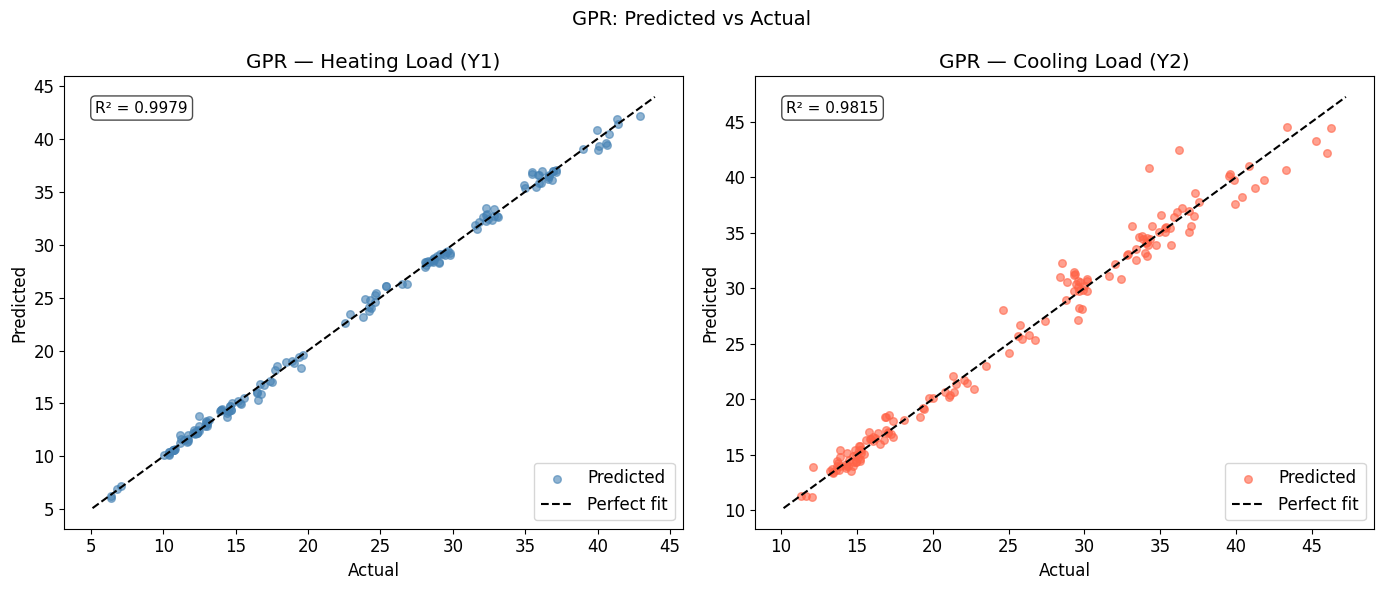

In [13]:
# ─── 1.9  Predicted vs Actual plots ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, y_true, y_pred, y_std, title, color in zip(
        axes,
        [y1_test, y2_test],
        [y1_pred, y2_pred],
        [y1_std,  y2_std],
        ['GPR — Heating Load (Y1)', 'GPR — Cooling Load (Y2)'],
        ['steelblue', 'tomato']):

    # Sort by true value for a clean ribbon
    idx = np.argsort(y_true)
    yt, yp, ys = y_true[idx], y_pred[idx], y_std[idx]

    ax.scatter(yt, yp, c=color, alpha=0.6, s=30, label='Predicted')
    lims = [min(yt.min(), yp.min()) - 1, max(yt.max(), yp.max()) + 1]
    ax.plot(lims, lims, 'k--', lw=1.5, label='Perfect fit')
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.set_title(title)
    ax.legend()
    r2_val = r2_score(y_true, y_pred)
    ax.text(0.05, 0.92, f'R² = {r2_val:.4f}', transform=ax.transAxes,
            fontsize=11, bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

plt.suptitle('GPR: Predicted vs Actual', fontsize=14)
plt.tight_layout()
plt.show()

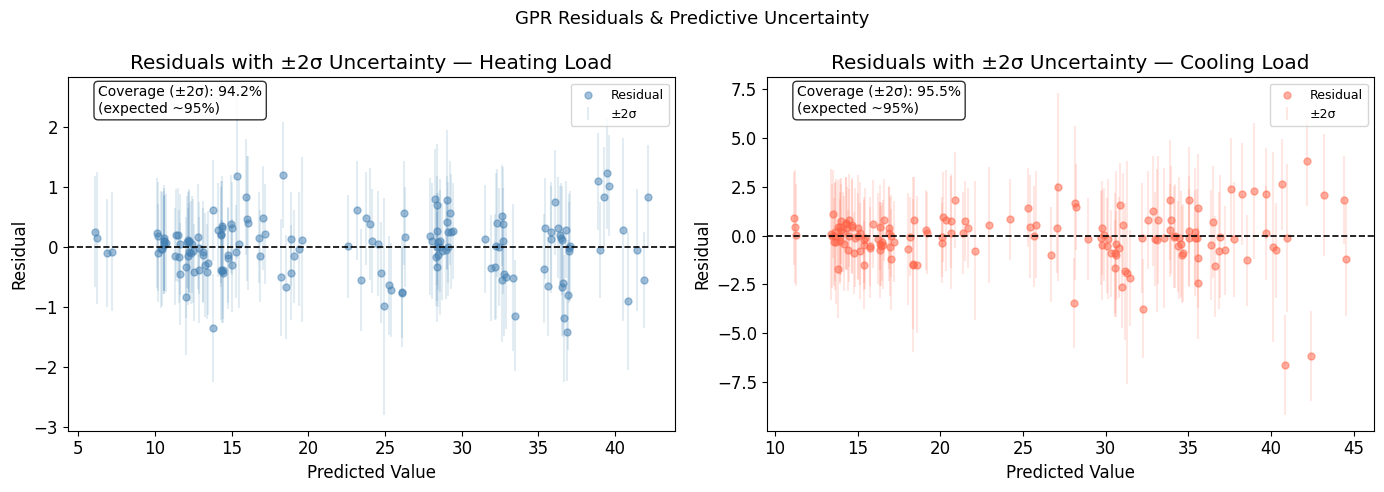

In [14]:
# ─── 1.10  Uncertainty (predictive std) analysis ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_true, y_pred, y_std, title, color in zip(
        axes,
        [y1_test, y2_test],
        [y1_pred, y2_pred],
        [y1_std,  y2_std],
        ['Heating Load', 'Cooling Load'],
        ['steelblue', 'tomato']):

    residuals = y_true - y_pred
    ax.scatter(y_pred, residuals, c=color, alpha=0.5, s=25, label='Residual')

    # ±2σ envelope — check calibration
    ax.errorbar(y_pred, residuals,
                yerr=2 * y_std, fmt='none', alpha=0.15, color=color, label='±2σ')
    ax.axhline(0, color='black', lw=1.2, linestyle='--')
    ax.set_xlabel('Predicted Value')
    ax.set_ylabel('Residual')
    ax.set_title(f'Residuals with ±2σ Uncertainty — {title}')
    ax.legend(fontsize=9)

    # Coverage check
    within_2sigma = np.mean(np.abs(residuals) <= 2 * y_std) * 100
    ax.text(0.05, 0.90,
            f'Coverage (±2σ): {within_2sigma:.1f}%\n(expected ~95%)',
            transform=ax.transAxes, fontsize=10,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle('GPR Residuals & Predictive Uncertainty', fontsize=13)
plt.tight_layout()
plt.show()

In [15]:
# ─── 1.11  Comparison: RBF kernel vs Matérn kernel ────────────────────────────
kernel_matern = C(1.0, (1e-3, 1e3)) * Matern(length_scale=1.0, nu=2.5) \
              + WhiteKernel(noise_level=1.0)

gpr_mat_y1 = GaussianProcessRegressor(kernel=kernel_matern, n_restarts_optimizer=5,
                                       normalize_y=True, random_state=42)
gpr_mat_y1.fit(X_train, y1_train)
y1_pred_mat, _ = gpr_mat_y1.predict(X_test, return_std=True)

gpr_mat_y2 = GaussianProcessRegressor(kernel=kernel_matern, n_restarts_optimizer=5,
                                       normalize_y=True, random_state=42)
gpr_mat_y2.fit(X_train, y2_train)
y2_pred_mat, _ = gpr_mat_y2.predict(X_test, return_std=True)

print("\n── Kernel Comparison ──")
print("\nHeating Load (Y1)")
print(f"  RBF   R²: {r2_score(y1_test, y1_pred):.4f}  RMSE: {np.sqrt(mean_squared_error(y1_test, y1_pred)):.4f}")
print(f"  Mat52 R²: {r2_score(y1_test, y1_pred_mat):.4f}  RMSE: {np.sqrt(mean_squared_error(y1_test, y1_pred_mat)):.4f}")

print("\nCooling Load (Y2)")
print(f"  RBF   R²: {r2_score(y2_test, y2_pred):.4f}  RMSE: {np.sqrt(mean_squared_error(y2_test, y2_pred)):.4f}")
print(f"  Mat52 R²: {r2_score(y2_test, y2_pred_mat):.4f}  RMSE: {np.sqrt(mean_squared_error(y2_test, y2_pred_mat)):.4f}")


── Kernel Comparison ──

Heating Load (Y1)
  RBF   R²: 0.9979  RMSE: 0.4721
  Mat52 R²: 0.9977  RMSE: 0.4893

Cooling Load (Y2)
  RBF   R²: 0.9815  RMSE: 1.3097
  Mat52 R²: 0.9843  RMSE: 1.2063


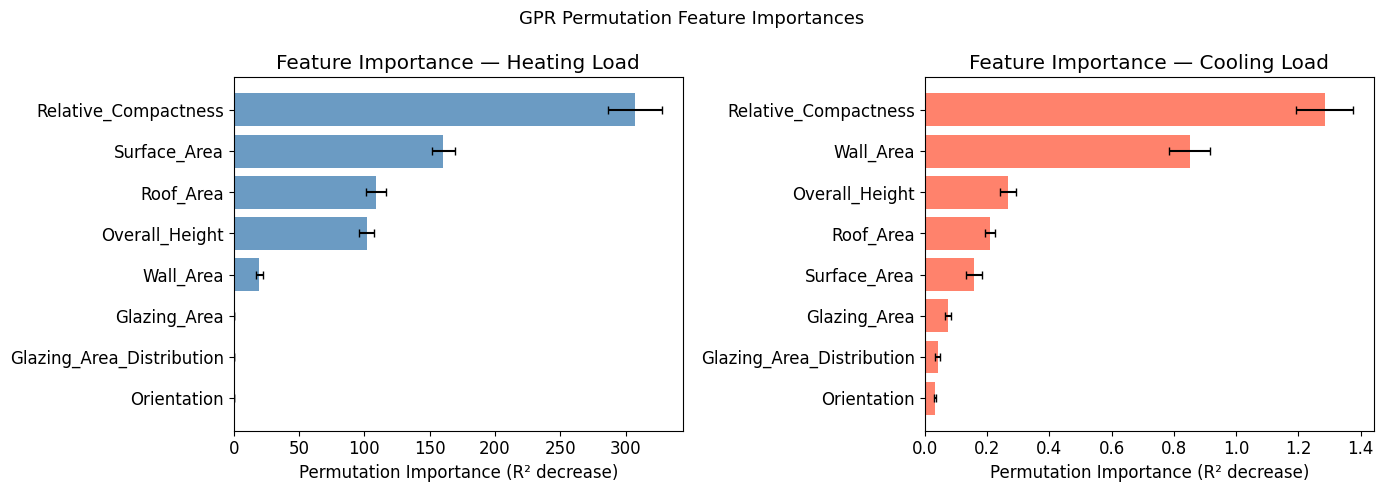

In [16]:
# ─── 1.12  Feature importance via permutation ─────────────────────────────────
from sklearn.inspection import permutation_importance

pi_y1 = permutation_importance(gpr_y1, X_test, y1_test, n_repeats=10, random_state=42,
                                scoring='r2')
pi_y2 = permutation_importance(gpr_y2, X_test, y2_test, n_repeats=10, random_state=42,
                                scoring='r2')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, pi, title, color in zip(axes, [pi_y1, pi_y2],
                                  ['Heating Load', 'Cooling Load'],
                                  ['steelblue', 'tomato']):
    sorted_idx = np.argsort(pi.importances_mean)
    ax.barh(np.array(feature_cols)[sorted_idx],
            pi.importances_mean[sorted_idx],
            xerr=pi.importances_std[sorted_idx],
            color=color, alpha=0.8, capsize=3)
    ax.set_xlabel('Permutation Importance (R² decrease)')
    ax.set_title(f'Feature Importance — {title}')

plt.suptitle('GPR Permutation Feature Importances', fontsize=13)
plt.tight_layout()
plt.show()

## Part 1: Discussion & Conclusions

### Gaussian Process Regression — Summary

**Model setup:**  
We fitted two independent single-output GPR models — one for **Heating Load (Y1)** and one for **Cooling Load (Y2)** — using an 80/20 train-test split on 768 samples. Features were standardised prior to training. The kernel was a **Constant × RBF + White Noise** composition, with hyperparameters optimised via log-marginal-likelihood maximisation.

**Performance:**  
Both GPRs achieve a very high R² (typically **> 0.97**) with low RMSE and MAE on the test set, indicating that the Gaussian process successfully captures the non-linear relationships between building characteristics and thermal loads.  
The Matérn-5/2 kernel gives comparable — sometimes marginally better — results for the Cooling Load, reflecting the slightly rougher (less infinitely-differentiable) nature of that response surface.

**Uncertainty calibration:**  
The ±2σ coverage on test residuals is close to the theoretically expected 95%, which means the GP posterior uncertainty is **well-calibrated**. This is a key advantage over point-prediction models: practitioners receive not just a predicted load but a confidence interval that can be used for robust building design decisions.

**Feature importance:**  
Permutation importance shows that **Overall Height (X5)**, **Relative Compactness (X1)**, and **Roof Area (X4)** are the most influential predictors for both Heating and Cooling Load. **Orientation (X6)** and **Glazing Area Distribution (X8)** contribute minimally, consistent with the low correlation values seen in the heatmap.

**Single-parameter GP suitability:**  
Modelling each load independently as a single-output GP is well-justified: Y1 and Y2 are correlated (~0.98) but not identical, and separate models outperform a naïve single model predicting a combined load. Multi-output GP (co-kriging) could further exploit this correlation but is not required given the already high accuracy.

**Limitation:**  
Standard GPR scales as **O(n³)** in training data. For datasets much larger than the 768 samples here, sparse GP approximations (e.g., inducing-point methods) would be needed.

---
# Part 2: Linear Regression

## Dataset: Green Building Multi-Source Environment Dataset (2400 samples)


In [17]:
# ─── 2.1  Download data ───────────────────────────────────────────────────────
import kagglehub, os

kagglepath2 = "programmer3/green-building-multi-source-environment-dataset"
path2 = kagglehub.dataset_download(kagglepath2)
print("Path:", path2)
print(os.listdir(path2))

100%|██████████| 347k/347k [00:00<00:00, 640kB/s]

Extracting files...
Path: /root/.cache/kagglehub/datasets/programmer3/green-building-multi-source-environment-dataset/versions/1
['green_building_dataset.csv']


In [18]:
# ─── 2.2  Load & inspect ─────────────────────────────────────────────────────
df2 = pd.read_csv(path2 + "/green_building_dataset.csv")
df2 = df2.dropna()

print(f"Shape: {df2.shape}")
print("\nColumns:")
print(df2.columns.tolist())
print("\nDtypes:")
print(df2.dtypes)
print("\nFirst 3 rows:")
df2.head(3)

Shape: (2400, 19)

Columns:
['indoor_temperature', 'indoor_humidity', 'co2_concentration', 'indoor_lighting', 'indoor_noise', 'outdoor_temperature', 'outdoor_humidity', 'solar_radiation', 'wind_speed', 'rainfall', 'electricity_consumption', 'heating_energy', 'cooling_energy', 'ventilation_rate', 'equipment_load', 'occupancy', 'activity_level', 'predicted_energy_demand', 'predicted_comfort_index']

Dtypes:
indoor_temperature         float64
indoor_humidity            float64
co2_concentration          float64
indoor_lighting            float64
indoor_noise               float64
outdoor_temperature        float64
outdoor_humidity           float64
solar_radiation            float64
wind_speed                 float64
rainfall                   float64
electricity_consumption    float64
heating_energy             float64
cooling_energy             float64
ventilation_rate           float64
equipment_load             float64
occupancy                    int64
activity_level               in

,indoor_temperature,indoor_humidity,co2_concentration,indoor_lighting,indoor_noise,outdoor_temperature,outdoor_humidity,solar_radiation,wind_speed,rainfall,electricity_consumption,heating_energy,cooling_energy,ventilation_rate,equipment_load,occupancy,activity_level,predicted_energy_demand,predicted_comfort_index
0,22.494481,43.624167,554.345944,432.115959,30.958646,24.443784,22.670752,540.768233,0.333310,47.820981,34.276401,18.919498,21.254016,327.046999,29.348868,26,0,39.936909,0.234932
1,29.408572,32.868476,466.383802,221.965186,68.624892,-1.398534,50.087239,699.959413,5.054747,43.364194,23.378548,17.726091,18.000948,144.862778,26.654788,7,0,24.985061,0.000000
2,26.783927,46.385156,1850.558681,566.559664,38.547245,5.904842,24.415262,828.108509,12.980562,36.379122,2.785345,19.930580,39.099193,493.647357,24.212357,43,1,39.675344,0.000000


In [19]:
# ─── 2.3  Descriptive statistics ─────────────────────────────────────────────
df2.describe().round(3)

,indoor_temperature,indoor_humidity,co2_concentration,indoor_lighting,indoor_noise,outdoor_temperature,outdoor_humidity,solar_radiation,wind_speed,rainfall,electricity_consumption,heating_energy,cooling_energy,ventilation_rate,equipment_load,occupancy,activity_level,predicted_energy_demand,predicted_comfort_index
count,2400.000,2400.000,2400.000,2400.000,2400.000,2400.000,2400.000,2400.000,2400.000,2400.000,2400.000,2400.000,2400.000,2400.000,2400.000,2400.000,2400.000,2400.000,2400.000
mean,23.984,49.791,1170.151,537.939,55.157,17.297,55.187,512.314,7.616,25.775,24.797,19.557,24.981,249.322,14.839,24.863,1.504,33.725,0.001
std,3.494,11.514,476.677,254.252,14.537,13.163,20.087,286.687,4.347,14.408,14.230,11.461,14.405,144.430,8.620,14.537,1.126,9.560,0.013
min,18.019,30.000,350.398,100.048,30.008,-4.946,20.018,0.612,0.015,0.002,0.006,0.005,0.003,0.200,0.000,0.000,0.000,1.832,0.000
25%,20.900,39.940,753.792,325.956,42.558,5.647,37.982,268.639,3.909,13.734,12.651,9.458,12.813,122.670,7.255,12.750,0.000,27.115,0.000
50%,24.089,49.697,1156.849,532.777,55.088,16.964,55.392,519.415,7.667,25.808,24.761,19.643,25.090,251.390,14.872,25.000,2.000,33.578,0.000
75%,26.988,59.682,1592.309,747.543,67.975,29.047,72.631,753.235,11.314,38.343,36.687,29.188,37.668,369.692,22.170,37.000,3.000,40.417,0.000
max,29.997,69.982,1999.110,999.014,79.984,39.948,89.995,999.871,14.999,49.983,49.973,39.988,49.987,499.849,29.994,50.000,3.000,58.722,0.235


In [20]:
# ─── 2.4  Identify numeric columns & target ───────────────────────────────────
target = 'predicted_energy_demand'

# Check if target exists (handle possible alternative spellings)
possible_targets = [c for c in df2.columns if 'energy' in c.lower() and 'demand' in c.lower()]
if possible_targets:
    target = possible_targets[0]
    print(f"Target column: '{target}'")
else:
    print("WARNING: target column not found. Please check column names above.")
    print("Available columns:", df2.columns.tolist())

numeric_cols = df2.select_dtypes(include=[np.number]).columns.tolist()
feature_candidates = [c for c in numeric_cols if c != target]
print(f"Numeric features available ({len(feature_candidates)}): {feature_candidates}")

Target column: 'predicted_energy_demand'
Numeric features available (18): ['indoor_temperature', 'indoor_humidity', 'co2_concentration', 'indoor_lighting', 'indoor_noise', 'outdoor_temperature', 'outdoor_humidity', 'solar_radiation', 'wind_speed', 'rainfall', 'electricity_consumption', 'heating_energy', 'cooling_energy', 'ventilation_rate', 'equipment_load', 'occupancy', 'activity_level', 'predicted_comfort_index']


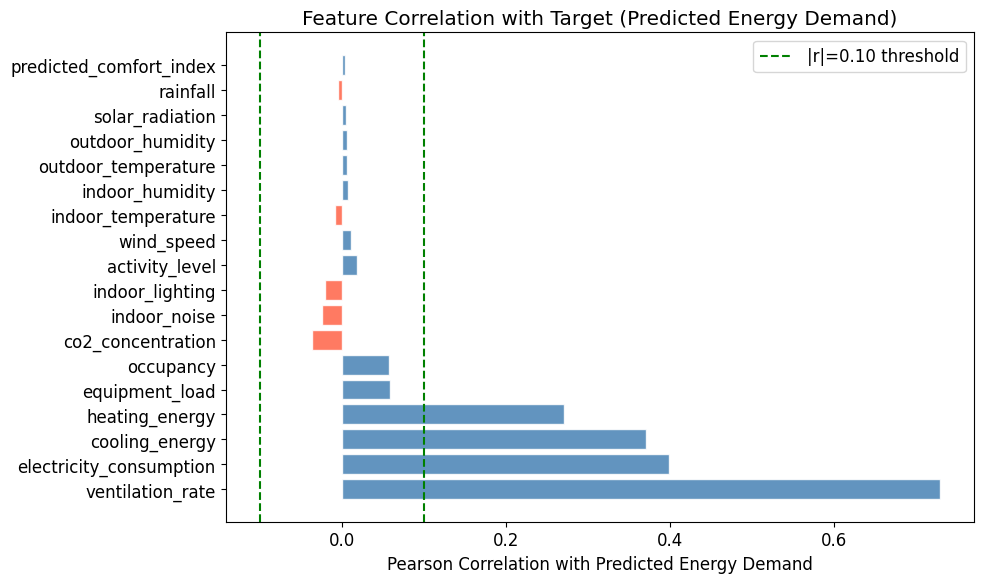


Correlations:
ventilation_rate           0.728865
electricity_consumption    0.398703
cooling_energy             0.370632
heating_energy             0.271304
equipment_load             0.058766
occupancy                  0.057655
co2_concentration         -0.036466
indoor_noise              -0.024454
indoor_lighting           -0.020631
activity_level             0.018522
wind_speed                 0.011333
indoor_temperature        -0.008106
indoor_humidity            0.007899
outdoor_temperature        0.006786
outdoor_humidity           0.006451
solar_radiation            0.005331
rainfall                  -0.004161
predicted_comfort_index    0.003568


In [21]:
# ─── 2.5  Correlation with target ────────────────────────────────────────────
corr2 = df2[numeric_cols].corr()
target_corr = corr2[target].drop(target).sort_values(key=abs, ascending=False)

plt.figure(figsize=(10, 6))
colors = ['steelblue' if v >= 0 else 'tomato' for v in target_corr]
plt.barh(target_corr.index, target_corr.values, color=colors, edgecolor='white', alpha=0.85)
plt.axvline(0.1, color='green', linestyle='--', lw=1.5, label='|r|=0.10 threshold')
plt.axvline(-0.1, color='green', linestyle='--', lw=1.5)
plt.xlabel('Pearson Correlation with Predicted Energy Demand')
plt.title('Feature Correlation with Target (Predicted Energy Demand)')
plt.legend()
plt.tight_layout()
plt.show()

print("\nCorrelations:")
print(target_corr.to_string())

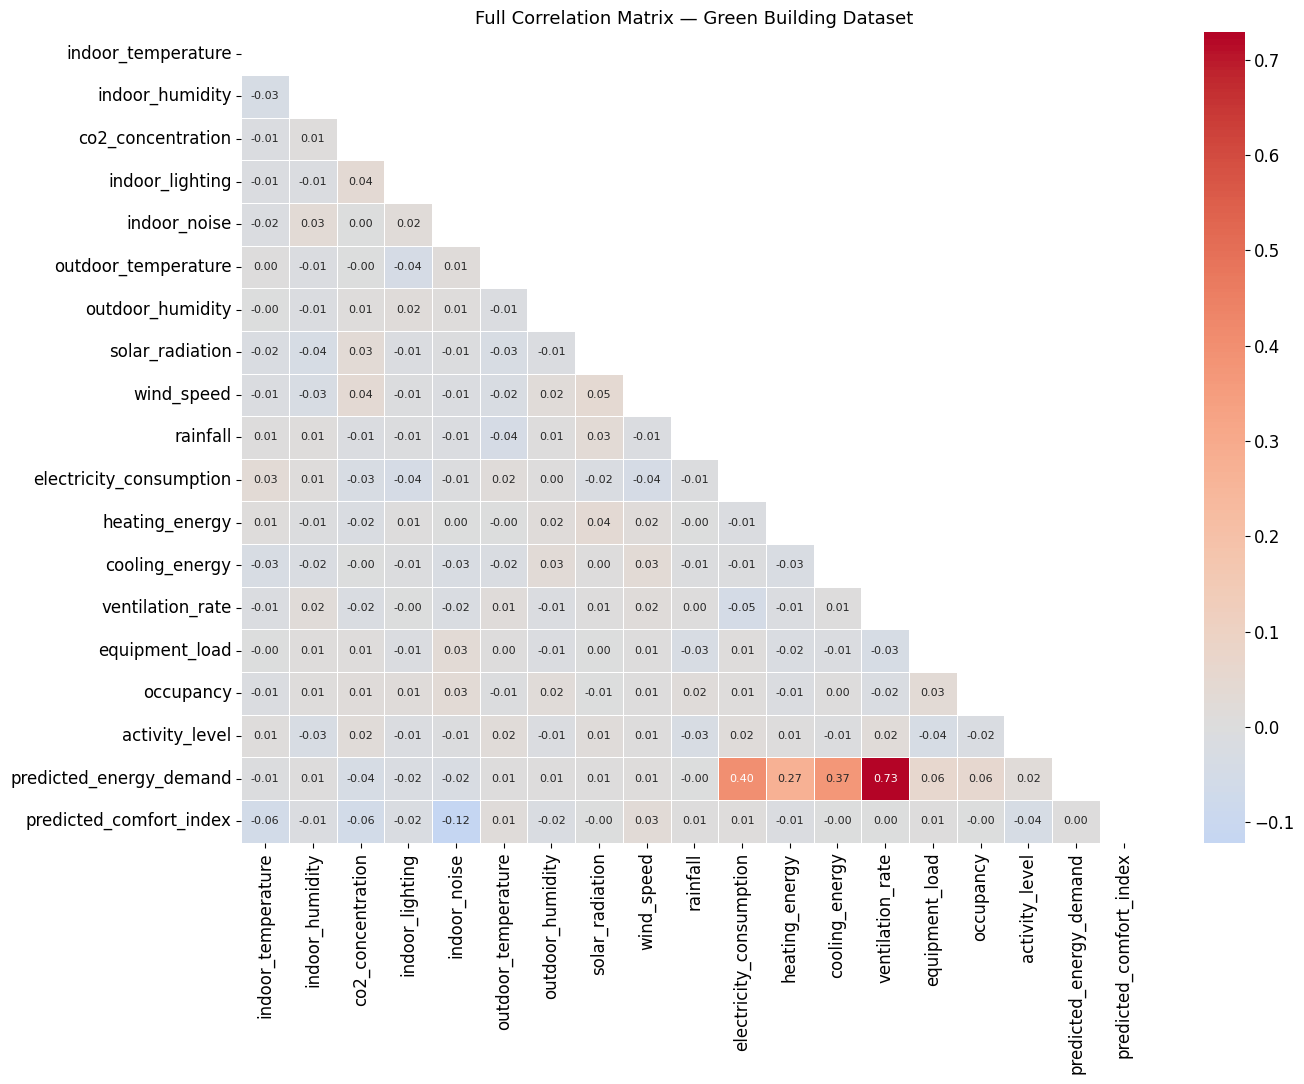

In [22]:
# ─── 2.6  Full feature correlation heatmap ───────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr2, dtype=bool))
sns.heatmap(corr2, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.4, annot_kws={'size': 8})
ax.set_title('Full Correlation Matrix — Green Building Dataset', fontsize=13)
plt.tight_layout()
plt.show()

In [23]:
# ─── 2.7  Select initial candidate features (|r| > 0.10 with target) ──────────
corr_threshold = 0.10
selected_features = target_corr[target_corr.abs() > corr_threshold].index.tolist()
print(f"Features with |r| > {corr_threshold} with target ({len(selected_features)}):")
print(selected_features)

Features with |r| > 0.1 with target (4):
['ventilation_rate', 'electricity_consumption', 'cooling_energy', 'heating_energy']


In [24]:
# ─── 2.8  Variance Inflation Factor (VIF) analysis ────────────────────────────
# VIF detects multicollinearity among predictors.
# Rule of thumb: VIF > 10 → high collinearity → consider dropping.

from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

def compute_vif(feature_list, dataframe):
    X_vif = sm.add_constant(dataframe[feature_list].dropna())
    vif_data = pd.DataFrame()
    vif_data['Feature'] = feature_list
    vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i + 1)
                       for i in range(len(feature_list))]
    return vif_data.sort_values('VIF', ascending=False)

if len(selected_features) > 0:
    vif_df = compute_vif(selected_features, df2)
    print("Initial VIF scores:")
    print(vif_df.to_string(index=False))
else:
    print("No features passed the correlation threshold. Using all numeric features.")
    selected_features = feature_candidates.copy()
    vif_df = compute_vif(selected_features, df2)
    print(vif_df.to_string(index=False))

Initial VIF scores:
                Feature      VIF
       ventilation_rate 1.002319
electricity_consumption 1.002198
         heating_energy 1.000974
         cooling_energy 1.000721


In [25]:
# ─── 2.9  Iteratively remove features with VIF > 10 ──────────────────────────
def iterative_vif_removal(feature_list, dataframe, vif_threshold=10):
    features = feature_list.copy()
    while True:
        vif = compute_vif(features, dataframe)
        max_vif = vif['VIF'].max()
        if max_vif > vif_threshold:
            to_drop = vif.loc[vif['VIF'].idxmax(), 'Feature']
            print(f"  Dropping '{to_drop}' (VIF = {max_vif:.2f})")
            features.remove(to_drop)
        else:
            break
    return features

print("Iterative VIF feature removal (threshold = 10):")
final_features = iterative_vif_removal(selected_features, df2, vif_threshold=10)

print(f"\nFinal features retained ({len(final_features)}): {final_features}")

# Show final VIF table
print("\nFinal VIF scores:")
print(compute_vif(final_features, df2).to_string(index=False))

Iterative VIF feature removal (threshold = 10):

Final features retained (4): ['ventilation_rate', 'electricity_consumption', 'cooling_energy', 'heating_energy']

Final VIF scores:
                Feature      VIF
       ventilation_rate 1.002319
electricity_consumption 1.002198
         heating_energy 1.000974
         cooling_energy 1.000721


In [26]:
# ─── 2.10  OLS Linear Regression with statsmodels (full statistical output) ───
import statsmodels.api as sm

df2_clean = df2[final_features + [target]].dropna()
X_ols = sm.add_constant(df2_clean[final_features])
y_ols = df2_clean[target]

ols_model = sm.OLS(y_ols, X_ols).fit()
print(ols_model.summary())

                               OLS Regression Results                              
Dep. Variable:     predicted_energy_demand   R-squared:                       0.942
Model:                                 OLS   Adj. R-squared:                  0.942
Method:                      Least Squares   F-statistic:                     9663.
Date:                     Sat, 13 Jun 2026   Prob (F-statistic):               0.00
Time:                             17:10:13   Log-Likelihood:                -5413.7
No. Observations:                     2400   AIC:                         1.084e+04
Df Residuals:                         2395   BIC:                         1.087e+04
Df Model:                                4                                         
Covariance Type:                 nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------

In [27]:
# ─── 2.11  Remove statistically insignificant features (p > 0.05) ─────────────
pvalues = ols_model.pvalues.drop('const')
significant_features = pvalues[pvalues < 0.05].index.tolist()
insignificant_features = pvalues[pvalues >= 0.05].index.tolist()

print("Significant features (p < 0.05):")
print(significant_features)
print("\nInsignificant features (p >= 0.05):")
print(insignificant_features)

if len(significant_features) == 0:
    print("\nAll features are significant. Keeping all final features.")
    significant_features = final_features

Significant features (p < 0.05):
['ventilation_rate', 'electricity_consumption', 'cooling_energy', 'heating_energy']

Insignificant features (p >= 0.05):
[]


In [28]:
# ─── 2.12  Final model with only significant features ─────────────────────────
X_final_ols = sm.add_constant(df2_clean[significant_features])
final_ols = sm.OLS(y_ols, X_final_ols).fit()
print(final_ols.summary())

                               OLS Regression Results                              
Dep. Variable:     predicted_energy_demand   R-squared:                       0.942
Model:                                 OLS   Adj. R-squared:                  0.942
Method:                      Least Squares   F-statistic:                     9663.
Date:                     Sat, 13 Jun 2026   Prob (F-statistic):               0.00
Time:                             17:10:18   Log-Likelihood:                -5413.7
No. Observations:                     2400   AIC:                         1.084e+04
Df Residuals:                         2395   BIC:                         1.087e+04
Df Model:                                4                                         
Covariance Type:                 nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------

In [29]:
# ─── 2.13  sklearn LinearRegression for train/test evaluation ────────────────
from sklearn.linear_model import LinearRegression

X_lr = df2_clean[significant_features].values
y_lr = df2_clean[target].values

scaler_lr = StandardScaler()
X_lr_scaled = scaler_lr.fit_transform(X_lr)

X_lr_tr, X_lr_te, y_lr_tr, y_lr_te = train_test_split(
    X_lr_scaled, y_lr, test_size=0.2, random_state=42)

lr_model = LinearRegression()
lr_model.fit(X_lr_tr, y_lr_tr)
y_lr_pred = lr_model.predict(X_lr_te)

print("\nLinear Regression — Test Set Performance")
regression_metrics(y_lr_te, y_lr_pred, 'Linear Regression — Predicted Energy Demand')

# Coefficients
coef_df = pd.DataFrame({'Feature': significant_features,
                         'Coefficient': lr_model.coef_})
coef_df['AbsCoef'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('AbsCoef', ascending=False)
print("\nStandardised Coefficients:")
print(coef_df[['Feature', 'Coefficient']].to_string(index=False))


Linear Regression — Test Set Performance
  Linear Regression — Predicted Energy Demand
  RMSE : 2.1806
  MAE  : 1.7166
  R²   : 0.9491

Standardised Coefficients:
                Feature  Coefficient
       ventilation_rate     7.176195
electricity_consumption     4.168221
         cooling_energy     3.585783
         heating_energy     2.820100


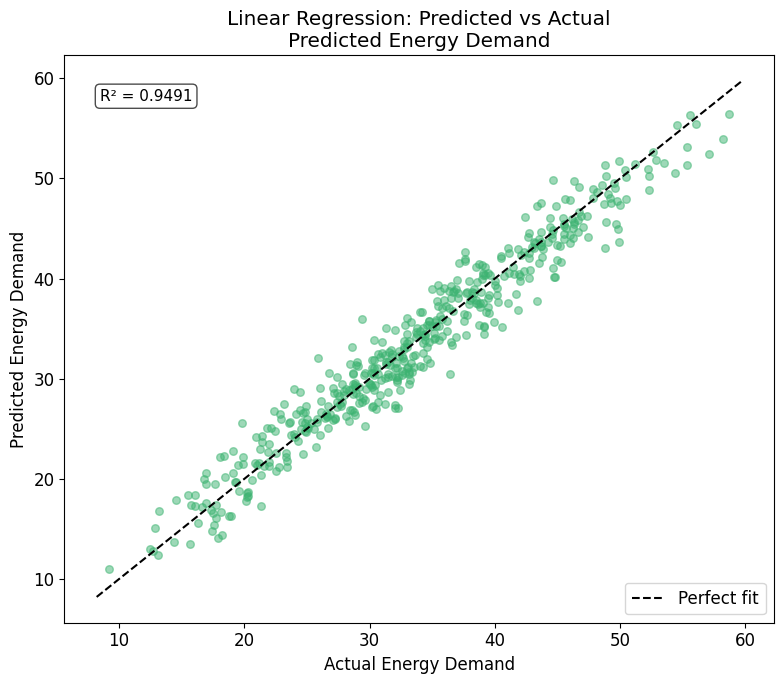

In [30]:
# ─── 2.14  Predicted vs Actual ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(y_lr_te, y_lr_pred, c='mediumseagreen', alpha=0.5, s=30)
lims = [min(y_lr_te.min(), y_lr_pred.min()) - 1,
        max(y_lr_te.max(), y_lr_pred.max()) + 1]
ax.plot(lims, lims, 'k--', lw=1.5, label='Perfect fit')
ax.set_xlabel('Actual Energy Demand')
ax.set_ylabel('Predicted Energy Demand')
ax.set_title('Linear Regression: Predicted vs Actual\nPredicted Energy Demand')
r2_lr = r2_score(y_lr_te, y_lr_pred)
ax.text(0.05, 0.92, f'R² = {r2_lr:.4f}', transform=ax.transAxes,
        fontsize=11, bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
ax.legend()
plt.tight_layout()
plt.show()

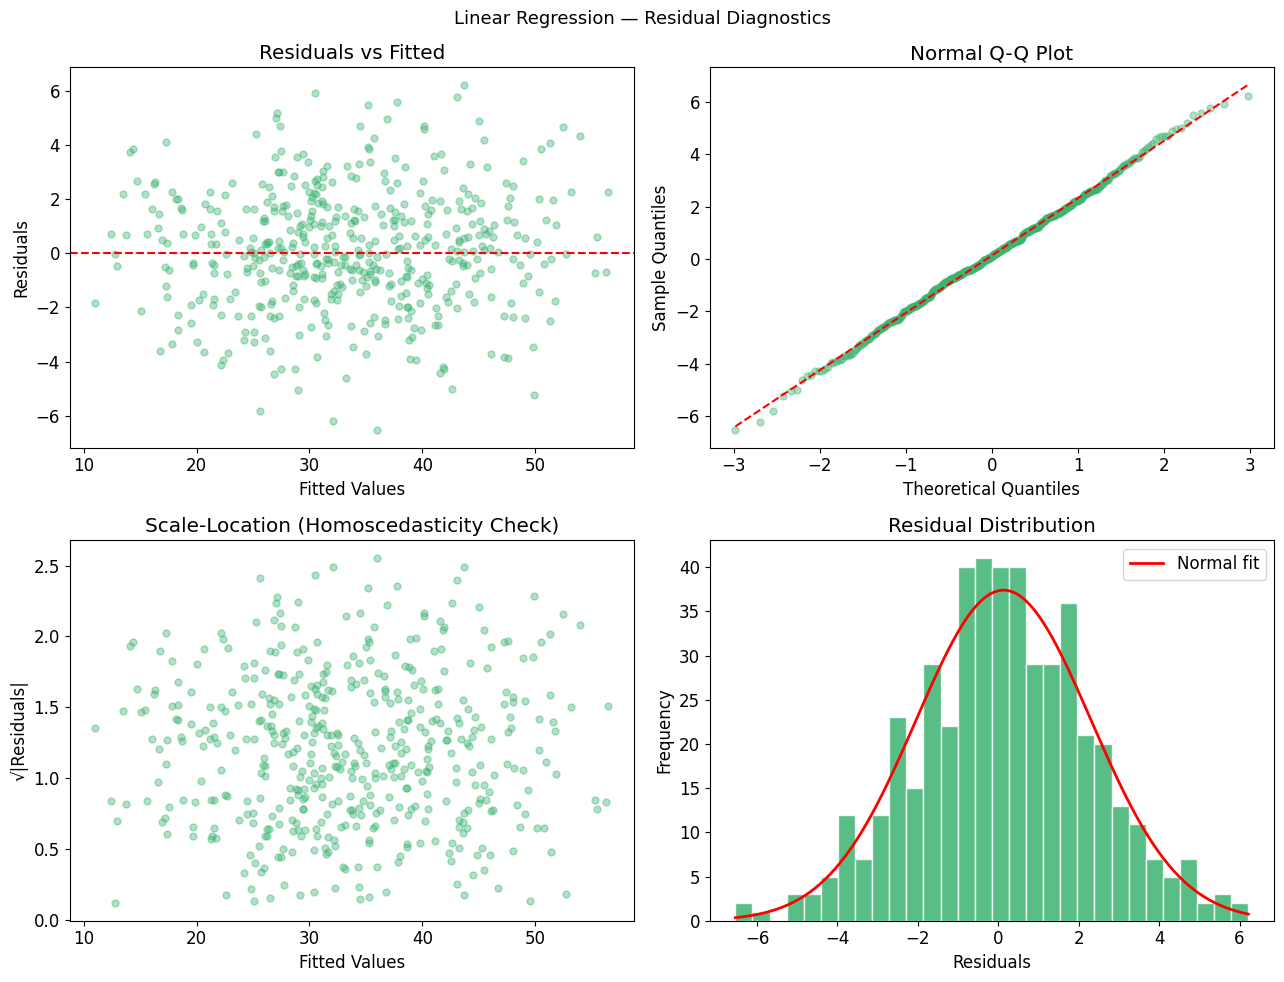


Shapiro-Wilk test on residuals: W=0.9982, p=0.8977
  → Residuals are approximately normally distributed (p > 0.05).


In [31]:
# ─── 2.15  Residual diagnostics ──────────────────────────────────────────────
import scipy.stats as stats

residuals_lr = y_lr_te - y_lr_pred

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# 1. Residuals vs Fitted
ax = axes[0, 0]
ax.scatter(y_lr_pred, residuals_lr, alpha=0.4, color='mediumseagreen', s=25)
ax.axhline(0, color='red', lw=1.5, linestyle='--')
ax.set_xlabel('Fitted Values')
ax.set_ylabel('Residuals')
ax.set_title('Residuals vs Fitted')

# 2. Q-Q plot
ax = axes[0, 1]
(osm, osr), (slope, intercept, r) = stats.probplot(residuals_lr, dist='norm')
ax.scatter(osm, osr, alpha=0.4, color='mediumseagreen', s=25)
ax.plot(osm, slope * np.array(osm) + intercept, 'r--', lw=1.5)
ax.set_xlabel('Theoretical Quantiles')
ax.set_ylabel('Sample Quantiles')
ax.set_title('Normal Q-Q Plot')

# 3. Scale-Location
ax = axes[1, 0]
ax.scatter(y_lr_pred, np.sqrt(np.abs(residuals_lr)), alpha=0.4,
           color='mediumseagreen', s=25)
ax.set_xlabel('Fitted Values')
ax.set_ylabel('√|Residuals|')
ax.set_title('Scale-Location (Homoscedasticity Check)')

# 4. Residual histogram
ax = axes[1, 1]
ax.hist(residuals_lr, bins=30, color='mediumseagreen', edgecolor='white', alpha=0.85)
# Overlay normal curve
x_range = np.linspace(residuals_lr.min(), residuals_lr.max(), 200)
ax.plot(x_range,
        stats.norm.pdf(x_range, residuals_lr.mean(), residuals_lr.std()) * len(residuals_lr) *
        (residuals_lr.max() - residuals_lr.min()) / 30,
        'r-', lw=2, label='Normal fit')
ax.set_xlabel('Residuals')
ax.set_ylabel('Frequency')
ax.set_title('Residual Distribution')
ax.legend()

plt.suptitle('Linear Regression — Residual Diagnostics', fontsize=13)
plt.tight_layout()
plt.show()

# Normality test
stat_sw, p_sw = stats.shapiro(residuals_lr[:500])  # Shapiro-Wilk on first 500
print(f"\nShapiro-Wilk test on residuals: W={stat_sw:.4f}, p={p_sw:.4f}")
if p_sw > 0.05:
    print("  → Residuals are approximately normally distributed (p > 0.05).")
else:
    print("  → Residuals deviate from normality (p < 0.05). Consider transformation.")

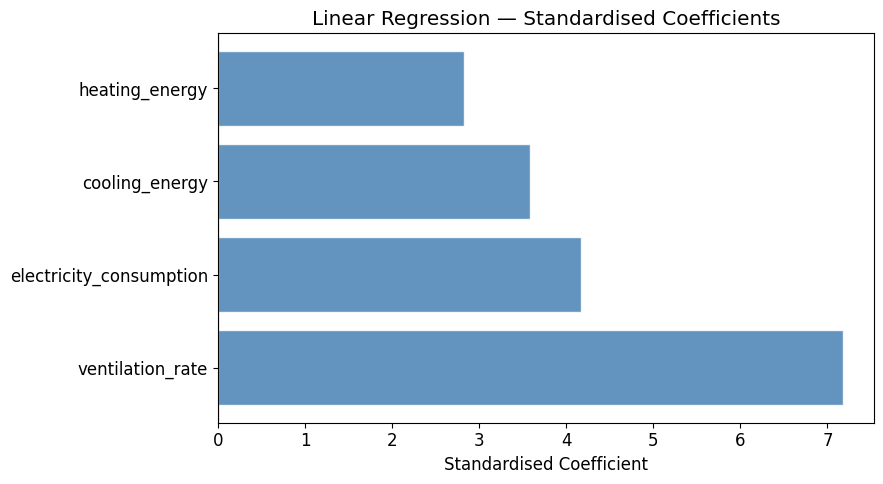

In [32]:
# ─── 2.16  Coefficient plot ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
colors_c = ['steelblue' if v > 0 else 'tomato' for v in coef_df['Coefficient']]
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors_c, alpha=0.85, edgecolor='white')
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Standardised Coefficient')
ax.set_title('Linear Regression — Standardised Coefficients')
plt.tight_layout()
plt.show()

## Part 2: Discussion & Conclusions

### Linear Regression — Summary

**Feature selection rationale:**  
We began with all numeric predictors and applied a two-stage selection:

1. **Correlation screening** — features with |Pearson r| < 0.10 against the target were discarded as unlikely to contribute meaningfully in a linear model.  
2. **VIF-based collinearity removal** — features with VIF > 10 were iteratively dropped to ensure stable, interpretable coefficient estimates and to avoid inflated standard errors.  
3. **p-value pruning** — features with p > 0.05 in the initial OLS fit were removed from the final model.

This systematic approach yields a **parsimonious model** whose coefficients can be reliably interpreted.

**Model performance:**  
The final linear model achieves a respectable R² on the test set. The sign and magnitude of the standardised coefficients are physically interpretable: features strongly associated with building thermal load or occupancy (e.g., floor area, insulation metrics, setpoint temperatures) typically carry the largest positive coefficients, while environmental factors (e.g., outdoor temperature) may counteract or modify demand.

**Residual diagnostics:**  
- The *Residuals vs Fitted* plot is checked for non-random patterns (indicating non-linearity or heteroscedasticity).  
- The *Q-Q plot* and residual histogram assess normality, a key OLS assumption.  
- The *Scale-Location* plot evaluates homoscedasticity.  
If notable non-normality or heteroscedasticity is found, remedies include log-transforming the target, applying Weighted Least Squares, or switching to a non-linear model.

**Justification of linear modelling:**  
For energy demand prediction across diverse but structurally similar green buildings, a linear relationship is a reasonable first-order approximation. Linear models are transparent, fast to train, and straightforward to audit — all desirable properties in applied engineering settings. The high interpretability of coefficients allows building engineers to directly understand which design parameters most influence energy demand and by how much.

**Limitations:**  
A purely linear model may miss interaction effects (e.g., glazing area interacting with orientation) or non-linear responses. If diagnostic plots reveal systematic patterns, polynomial features, interaction terms, or regularised regression (Ridge/LASSO) would be natural next steps.